# GROUP 11 - SET 11

In [129]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime

In [2]:
# ==============================
# 2. CONFIGURATION
# ==============================

RUNS_DIRECTORY = "../data/runs"

qrels_file = "../data/qrels.trec8.adhoc"

OUTPUT_FOLDER = "../data/output"

FILE_PATTERN = "input.*"

DOC_THRESHOLD = 1000

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

## 1.0 Data Cleaning

In [3]:
def read_clean_trec(file_path):
    column_names = ["query_id", "Q0", "doc_id", "rank", "score", "system_name"]

    try:
        df = pd.read_csv(
            file_path,
            sep=r'\s+',
            engine='python',
            names=column_names,
            dtype=str
        )
    except Exception as e:
        print(f"ERROR reading {file_path}: {e}")
        return pd.DataFrame()

    df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")

    df = df.drop(columns=["Q0"])

    df = df.dropna(
        subset=["query_id", "doc_id", "rank", "score", "system_name"]
    ).copy()

    # Rebuild rank based on score descending
    df = df.sort_values(
        ["query_id", "score"],
        ascending=[True, False]
    ).copy()

    df["rank"] = df.groupby("query_id").cumcount() + 1
    df["rank"] = df["rank"].astype(int)

    return df

In [4]:
# ==============================
# 4. LOAD ALL RUN FILES
# ==============================

def load_all_runs(directory, pattern):
    file_paths = glob.glob(os.path.join(directory, pattern))

    if not file_paths:
        raise ValueError("No files found in the specified directory.")

    print(f"Found {len(file_paths)} files. Loading...")

    dataframes = []

    for file_path in file_paths:
        df = read_clean_trec(file_path)

        if not df.empty:
            dataframes.append(df)
            print(f"Loaded: {os.path.basename(file_path)} | rows: {len(df)}")
        else:
            print(f"Skipped empty/error file: {os.path.basename(file_path)}")

    clean_data = pd.concat(dataframes, ignore_index=True)

    clean_data = clean_data.sort_values(
        by=["system_name", "query_id", "rank"],
        ascending=[True, True, True]
    ).copy()

    return clean_data

In [5]:
# ==============================
# 5. RUN BASIC CLEANING
# ==============================

print(f"Attempting to load files from: {RUNS_DIRECTORY}")
if not os.path.exists(RUNS_DIRECTORY):
    print(f"Error: The directory {RUNS_DIRECTORY} does not exist.")
else:
    files_in_dir = os.listdir(RUNS_DIRECTORY)
    print(f"Files found in directory {RUNS_DIRECTORY}: {files_in_dir}")
    if not files_in_dir:
        print(f"Warning: The directory {RUNS_DIRECTORY} is empty.")

clean_data = load_all_runs(RUNS_DIRECTORY, FILE_PATTERN)

print("\nTotal cleaned rows:", len(clean_data))
display(clean_data.head())

Attempting to load files from: ../data/runs
Files found in directory ../data/runs: ['input.Mer8Adtd2', 'input.ibms99b', 'input.CL99XT', 'input.fub99a', 'input.apl8c621', 'input.acsys8alo', 'input.pir9Attd', 'input.Dm8TFidf', 'input.INQ601', 'input.nttd8ale', 'input.GE8ATDN2', 'input.acsys8alo2', 'input.ok8asxc', 'input.att99atde', 'input.apl8ctd']
Found 15 files. Loading...
Loaded: input.Mer8Adtd2 | rows: 50000
Loaded: input.ibms99b | rows: 50000
Loaded: input.CL99XT | rows: 50000
Loaded: input.fub99a | rows: 50000
Loaded: input.apl8c621 | rows: 50000
Loaded: input.acsys8alo | rows: 50000
Loaded: input.pir9Attd | rows: 50000
Loaded: input.Dm8TFidf | rows: 50000
Loaded: input.INQ601 | rows: 50000
Loaded: input.nttd8ale | rows: 50000
Loaded: input.GE8ATDN2 | rows: 50000
Loaded: input.acsys8alo2 | rows: 50000
Loaded: input.ok8asxc | rows: 50000
Loaded: input.att99atde | rows: 50000
Loaded: input.apl8ctd | rows: 50000

Total cleaned rows: 750000


,query_id,doc_id,rank,score,system_name
100000,401,FT932-15086,1,11173.180,CL99XT
100001,401,FT944-6909,2,10887.392,CL99XT
100002,401,FT943-15609,3,10854.055,CL99XT
100003,401,FT924-7265,4,10381.393,CL99XT
100004,401,FBIS4-67877,5,562.130,CL99XT


In [6]:
# ==============================
# 6. BASIC VALIDATION
# ==============================

print("Data types:")
print(clean_data.dtypes)

print("\nMissing values:")
print(clean_data.isna().sum())

print("\nRank start check:")
print(clean_data.groupby(["system_name", "query_id"])["rank"].min().value_counts())

Data types:
query_id           str
doc_id             str
rank             int64
score          float64
system_name        str
dtype: object

Missing values:
query_id       0
doc_id         0
rank           0
score          0
system_name    0
dtype: int64

Rank start check:
rank
1    750
Name: count, dtype: int64


In [7]:
# ==============================
# 7. CHECK DUPLICATES
# ==============================

duplicates = clean_data.duplicated(
    subset=["system_name", "query_id", "doc_id"]
)

if duplicates.any():
    print("WARNING: Duplicate documents detected.")
    display(clean_data[duplicates].head())
else:
    print("OK: No duplicate documents found.")

OK: No duplicate documents found.


In [8]:
# ==============================
# 8. CHECK DOCUMENT COUNT PER ENTRY
# ==============================

query_doc_counts = (
    clean_data.groupby(["system_name", "query_id"])
    .size()
    .reset_index(name="doc_count")
)

display(query_doc_counts.head())

insufficient_queries = query_doc_counts[query_doc_counts["doc_count"] < DOC_THRESHOLD]

if not insufficient_queries.empty:
    print("WARNING: Some system-query pairs have fewer than 1000 documents.")
    display(insufficient_queries)
else:
    print("OK: All system-query pairs have enough documents.")

,system_name,query_id,doc_count
0,CL99XT,401,1000
1,CL99XT,402,1000
2,CL99XT,403,1000
3,CL99XT,404,1000
4,CL99XT,405,1000


OK: All system-query pairs have enough documents.


In [9]:
# ==============================
# 10. LOAD QRELS FILE
# ==============================

qrels_df = pd.read_csv(
    qrels_file,
    sep=r'\s+',
    header=None,
    names=["query_id", "ignore", "doc_id", "relevance"]
)

qrels_df.drop(columns=["ignore"], inplace=True)

print("Qrels loaded:", len(qrels_df), "rows")
display(qrels_df.head())

Qrels loaded: 86830 rows


,query_id,doc_id,relevance
0,401,FBIS3-10009,0
1,401,FBIS3-10059,0
2,401,FBIS3-10142,0
3,401,FBIS3-1026,0
4,401,FBIS3-10502,0


In [10]:
# ==============================
# 11. MATCH DATA TYPES BEFORE MERGING LATER
# ==============================

clean_data["query_id"] = clean_data["query_id"].astype(str)
clean_data["doc_id"] = clean_data["doc_id"].astype(str)

qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)
qrels_df["relevance"] = pd.to_numeric(qrels_df["relevance"], errors="coerce").fillna(0).astype(int)
# Convert any graded relevance (like 2) down to 1 to ensure binary relevance
qrels_df.loc[qrels_df["relevance"] > 1, "relevance"] = 1

In [11]:
# ==============================
# 12. EXPORT BASIC CLEAN DATA
# ==============================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

clean_file = os.path.join(OUTPUT_FOLDER, f"clean_runs_{timestamp}.csv")

clean_data.to_csv(clean_file, index=False)

print("Exported clean data:")
print(clean_file)

Exported clean data:
../data/output/clean_runs_20260523_123204.csv


### 1.1 Preparation for Analysis

In [12]:
## merge
merged_df = pd.merge(
    clean_data,
    qrels_df,
    on=['query_id', 'doc_id'],
    how='left'
)

merged_df['relevance'] = merged_df['relevance'].fillna(0).astype(int)

print(merged_df.head())

  query_id       doc_id  rank      score system_name  relevance
0      401  FT932-15086     1  11173.180      CL99XT          1
1      401   FT944-6909     2  10887.392      CL99XT          1
2      401  FT943-15609     3  10854.055      CL99XT          0
3      401   FT924-7265     4  10381.393      CL99XT          0
4      401  FBIS4-67877     5    562.130      CL99XT          0


In [13]:
## handle missing relevance
## document not in qrel = not relevant

print("Relevance distribution:")
print(merged_df['relevance'].value_counts())

print("\nMissing relevance:")
print(merged_df['relevance'].isna().sum())

print("\nCheck at least one relevant per query:")
print(
    merged_df.groupby(['system_name','query_id'])['relevance'].sum().head()
)
merged_df['relevance'].isna().sum()


Relevance distribution:
relevance
0    704123
1     45877
Name: count, dtype: int64

Missing relevance:
0

Check at least one relevant per query:
system_name  query_id
CL99XT       401         172
             402          64
             403          21
             404         112
             405          35
Name: relevance, dtype: int64


np.int64(0)

In [14]:
## sort data properly
merged_df = merged_df.sort_values(
    ['system_name', 'query_id', 'rank']
).copy()

In [15]:
## quick validation
print("Check relevance distribution:")
print(merged_df['relevance'].value_counts())

print("\nCheck one query:")
display(merged_df[merged_df['query_id'] == '401'].head(10))

Check relevance distribution:
relevance
0    704123
1     45877
Name: count, dtype: int64

Check one query:


,query_id,doc_id,rank,score,system_name,relevance
0,401,FT932-15086,1,11173.180,CL99XT,1
1,401,FT944-6909,2,10887.392,CL99XT,1
2,401,FT943-15609,3,10854.055,CL99XT,0
3,401,FT924-7265,4,10381.393,CL99XT,0
4,401,FBIS4-67877,5,562.130,CL99XT,0
5,401,FBIS4-67533,6,542.709,CL99XT,0
6,401,FT934-9441,7,304.628,CL99XT,0
7,401,FT924-11400,8,286.923,CL99XT,1
8,401,FBIS3-18410,9,271.099,CL99XT,0
9,401,FT941-16483,10,264.945,CL99XT,0


## 2.0 Data Analysis


#### 2.1 Precision

##### Precision@10

In [16]:
## STEP 1: Precision@10 (per-topic)

def precision_at_10(group):
    # sort by score descending (as per your choice)
    group_sorted = group.sort_values(by='score', ascending=False).head(10)

    # compute precision@10
    return group_sorted['relevance'].sum() / 10

# compute per-topic P@10
p10_results = (
    merged_df
    .groupby(['system_name', 'query_id'])
    .apply(precision_at_10)
    .reset_index(name='P@10')
)

print("Per-topic Precision@10:")
display(p10_results.sample(15))

Per-topic Precision@10:


,system_name,query_id,P@10
194,INQ601,445,0.9
381,apl8c621,432,0.0
641,nttd8ale,442,0.1
283,acsys8alo,434,0.9
399,apl8c621,450,1.0
487,att99atde,438,0.8
4,CL99XT,405,0.6
406,apl8ctd,407,0.8
473,att99atde,424,0.7
593,ibms99b,444,0.7


In [17]:
## STEP 2: Precision@10 (per-system)

avg_p10 = (
    p10_results
    .groupby('system_name')['P@10']
    .mean()
    .reset_index(name='Mean_P@10')
)

print("\nOverall Precision@10 per system:")

for _, row in avg_p10.iterrows():
    print(f"System: {row['system_name']} - Mean Precision@10: {row['Mean_P@10']:.4f}")


Overall Precision@10 per system:
System: CL99XT - Mean Precision@10: 0.6920
System: Dm8TFidf - Mean Precision@10: 0.3440
System: GE8ATDN2 - Mean Precision@10: 0.5120
System: INQ601 - Mean Precision@10: 0.4360
System: Mer8Adtd2 - Mean Precision@10: 0.4440
System: acsys8alo - Mean Precision@10: 0.5300
System: acsys8alo2 - Mean Precision@10: 0.4740
System: apl8c621 - Mean Precision@10: 0.5040
System: apl8ctd - Mean Precision@10: 0.4500
System: att99atde - Mean Precision@10: 0.5480
System: fub99a - Mean Precision@10: 0.5300
System: ibms99b - Mean Precision@10: 0.4600
System: nttd8ale - Mean Precision@10: 0.4940
System: ok8asxc - Mean Precision@10: 0.4880
System: pir9Attd - Mean Precision@10: 0.5080


##### Precision at k

In [18]:
k_values = [1, 10, 50, 500, 1000]

def precision_at_k(group, k):
    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)
    # Safely handle graded relevance (>0) and divide by k
    relevant_count = (group_sorted['relevance'] > 0).sum()
    return relevant_count / k

precision_results = {}
avg_precision_results = {}
precision_matrix_results = {}

# Ensure the output folder exists
os.makedirs(f"{OUTPUT_FOLDER}/PRECISION", exist_ok=True)

for k in k_values:
    # 1. Per system-per query Precision@k
    result = (
        merged_df
        .groupby(['system_name', 'query_id'])
        .apply(lambda x: precision_at_k(x, k))
        .reset_index(name=f'P@{k}')
    )
    precision_results[k] = result

    # 2. Average Precision@k per system (for summary table later)
    avg_result = (
        result
        .groupby('system_name')[f'P@{k}']
        .mean()
        .reset_index(name=f'Mean_P@{k}')
    )
    avg_precision_results[k] = avg_result

    # =========================================================
    # 3. FORMAT INTO PIVOT MATRIX (Like Image)
    # =========================================================

    # Pivot: Rows = query_id, Columns = system_name
    matrix_df = result.pivot(index='query_id', columns='system_name', values=f'P@{k}').reset_index()

    # Get just the system columns
    system_cols = [col for col in matrix_df.columns if col != 'query_id']

    # Add 'Overall' column (row-wise mean)
    matrix_df['Overall'] = matrix_df[system_cols].mean(axis=1)

    # Calculate 'Overall' row (column-wise mean)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row['query_id'] = 'Overall'
    overall_row['Overall'] = matrix_df['Overall'].mean()

    # Append the Overall row to the bottom
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this specific matrix to Google Drive
    file_path = f"{OUTPUT_FOLDER}/PRECISION/precision_at_{k}_matrix.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved Matrix: {file_path}")

    # Store for display
    precision_matrix_results[k] = matrix_df

Saved Matrix: ../data/output/PRECISION/precision_at_1_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_10_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_50_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_500_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_1000_matrix.csv


In [19]:
# DISPLAY AND SUMMARIZE RESULTS

# 1. Display the pivot matrix exactly like the picture (using k=10 as an example)
print("\n========== MATRIX FORMAT (Precision@10) ==========")
display(precision_matrix_results[10])

# 2. Combine Overall Precision scores into your final summary table
final_precision = avg_precision_results[k_values[0]]

for k in k_values[1:]:
    final_precision = pd.merge(
        final_precision,
        avg_precision_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL PRECISION SCORES ==========")
display(final_precision.sample(15))

# 3. Save the summary file
summary_path = f"{OUTPUT_FOLDER}/PRECISION/overall_precision_all_k.csv"
final_precision.to_csv(summary_path, index=False)
print(f"\nSaved overall precision summary to: {summary_path}")


========== MATRIX FORMAT (Precision@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.300,0.100,0.800,0.100,0.200,0.80,0.600,0.900,0.00,0.100,0.00,0.00,0.000,0.000,0.000,0.260000
1,402,0.700,0.600,0.800,0.300,0.600,0.90,0.800,0.900,0.80,0.800,0.70,0.20,0.700,0.700,0.300,0.653333
2,403,0.400,1.000,1.000,0.800,0.700,1.00,1.000,0.900,1.00,1.000,1.00,0.90,1.000,1.000,1.000,0.913333
3,404,0.600,0.500,0.500,0.200,0.400,0.30,0.400,0.400,0.40,0.400,0.50,0.20,0.200,0.300,0.500,0.386667
4,405,0.600,0.400,0.500,0.100,0.300,0.50,0.200,0.600,0.60,0.300,0.50,0.40,0.400,0.400,0.500,0.420000
5,406,0.600,0.200,0.300,0.300,0.400,0.60,0.400,0.600,0.60,0.600,0.50,0.50,0.400,0.600,0.500,0.473333
6,407,0.900,0.400,0.900,0.700,0.800,0.70,0.200,0.900,0.80,0.900,0.90,0.80,0.800,0.800,0.700,0.746667
7,408,0.800,0.500,0.300,0.200,0.400,0.00,0.200,0.200,0.30,0.300,0.30,0.30,0.500,0.400,0.400,0.340000
8,409,0.500,0.400,0.400,0.300,0.300,0.40,0.400,0.300,0.30,0.500,0.30,0.20,0.300,0.100,0.200,0.326667
9,410,1.000,1.000,1.000,1.000,1.000,1.00,1.000,1.000,1.00,1.000,1.00,1.00,1.000,1.000,1.000,1.000000



========== SUMMARY OVERALL PRECISION SCORES ==========


,system_name,Mean_P@1,Mean_P@10,Mean_P@50,Mean_P@500,Mean_P@1000
3,INQ601,0.44,0.436,0.2896,0.08716,0.05402
1,Dm8TFidf,0.56,0.344,0.1992,0.06044,0.03844
8,apl8ctd,0.56,0.450,0.2984,0.10260,0.06234
4,Mer8Adtd2,0.60,0.444,0.2788,0.09000,0.05662
7,apl8c621,0.66,0.504,0.3196,0.10988,0.06670
10,fub99a,0.70,0.530,0.3396,0.10880,0.06524
13,ok8asxc,0.58,0.488,0.3220,0.10120,0.06026
6,acsys8alo2,0.60,0.474,0.3168,0.10096,0.06160
5,acsys8alo,0.58,0.530,0.3452,0.11024,0.06624
9,att99atde,0.62,0.548,0.3572,0.11004,0.06512



Saved overall precision summary to: ../data/output/PRECISION/overall_precision_all_k.csv


### 2.2 MAP

In [20]:
# MAP@K CALCULATION

# 1. Total relevant documents per query (from qrels)
total_rel_per_query = (
    qrels_df[qrels_df['relevance'] > 0]
    .groupby('query_id')
    .size()
    .to_dict()
)


In [21]:
# 2. Function to calculate AP at a specific depth 'k'
def average_precision_at_k(group, k):
    # Get the query_id to look up the true total relevant docs
    qid = group.name[1]
    total_relevant = total_rel_per_query.get(qid, 0)

    # If the dataset has no relevant docs for this query, score is 0
    if total_relevant == 0:
        return 0.0

    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)

    relevant_count = 0
    precision_sum = 0

    # Fast loop using your itertuples method
    for i, row in enumerate(group_sorted.itertuples(), start=1):
        if row.relevance > 0:
            relevant_count += 1
            precision_sum += relevant_count / i

    # Divide by the TRUE total relevant, not the local amount!
    return precision_sum / total_relevant


ap_results = {}
map_results = {}
map_matrix_results = {}

# Create a folder to save the CSVs (optional, but keeps things clean)
os.makedirs(f"{OUTPUT_FOLDER}/MAP_Results", exist_ok=True)

for k in k_values:
    # 1. Calculate Per system-per query AP@k
    result = (
        merged_df
        .groupby(['system_name', 'query_id'])
        .apply(lambda x: average_precision_at_k(x, k))
        .reset_index(name=f'AP@{k}')
    )
    ap_results[k] = result

    # 2. Calculate MAP@k per system (for the summary table later)
    avg_map = (
        result
        .groupby('system_name')[f'AP@{k}']
        .mean()
        .reset_index(name=f'MAP@{k}')
    )
    map_results[k] = avg_map

    # Pivot the data: Rows = Topics (query_id), Columns = Systems
    matrix_df = result.pivot(index='query_id', columns='system_name', values=f'AP@{k}').reset_index()

    # Get a list of just the system columns
    system_cols = [col for col in matrix_df.columns if col != 'query_id']

    # Add 'Overall' column on the far right (Average of all systems for that topic)
    matrix_df['Overall'] = matrix_df[system_cols].mean(axis=1)

    # Calculate the 'Overall' row for the bottom (This is the MAP score for each system!)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row['query_id'] = 'Overall'
    overall_row['Overall'] = matrix_df['Overall'].mean() # Average of the averages

    # Append the Overall row to the bottom of the dataframe
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this beautiful matrix to a CSV file!
    file_path = f"{OUTPUT_FOLDER}/MAP_Results/MAP_at_{k}.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    # Store it in our dictionary so we can look at it in notebook
    map_matrix_results[k] = matrix_df

    print(f"Calculated and saved matrix for MAP@{k}")

Saved: ../data/output/MAP_Results/MAP_at_1.csv
Calculated and saved matrix for MAP@1
Saved: ../data/output/MAP_Results/MAP_at_10.csv
Calculated and saved matrix for MAP@10
Saved: ../data/output/MAP_Results/MAP_at_50.csv
Calculated and saved matrix for MAP@50
Saved: ../data/output/MAP_Results/MAP_at_500.csv
Calculated and saved matrix for MAP@500
Saved: ../data/output/MAP_Results/MAP_at_1000.csv
Calculated and saved matrix for MAP@1000


In [22]:
# DISPLAY THE RESULTS

# Show the matrix for k=10 as an example of what was saved to CSV
print("\n========== EXAMPLE MATRIX FORMAT (MAP@10) ==========")
display(map_matrix_results[10])

# Keep your excellent summary merging code!
# This creates a table comparing MAP@1, MAP@10, etc., side-by-side
final_map_summary = map_results[k_values[0]]
for k in k_values[1:]:
    final_map_summary = pd.merge(
        final_map_summary,
        map_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL MAP SCORES ==========")
display(final_map_summary)

# Optionally save the summary table too
final_map_summary.to_csv(
    f"{OUTPUT_FOLDER}/MAP_Results/overall_MAP_summary_all_k.csv",
    index=False
)


========== EXAMPLE MATRIX FORMAT (MAP@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.007917,0.000417,0.023348,0.000333,0.004444,0.018751,0.012417,0.029667,0.000000,0.000417,0.000000,0.000000,0.000000,0.000000,0.000000,0.006514
1,402,0.082937,0.065312,0.091597,0.017188,0.059137,0.112500,0.094722,0.106513,0.086443,0.095263,0.079568,0.020833,0.065729,0.066845,0.020238,0.070988
2,403,0.129365,0.476190,0.476190,0.341213,0.226587,0.476190,0.476190,0.423810,0.476190,0.476190,0.476190,0.428571,0.476190,0.476190,0.476190,0.420763
3,404,0.025156,0.019855,0.028672,0.002934,0.013190,0.009859,0.018310,0.025822,0.020736,0.009859,0.027582,0.005164,0.008803,0.008979,0.013777,0.015913
4,405,0.141667,0.065476,0.074196,0.002924,0.029449,0.083041,0.023684,0.127412,0.135673,0.049342,0.074687,0.044904,0.058406,0.033469,0.076754,0.068072
5,406,0.312546,0.089744,0.128205,0.186813,0.195360,0.327350,0.225275,0.253571,0.319658,0.379304,0.262821,0.299359,0.218315,0.338889,0.281197,0.254560
6,407,0.132353,0.058824,0.130882,0.099673,0.098693,0.068575,0.017974,0.132353,0.103560,0.132353,0.129248,0.106886,0.112868,0.117647,0.093627,0.102368
7,408,0.065042,0.035381,0.012107,0.008475,0.024247,0.000000,0.003578,0.011299,0.008898,0.017302,0.025424,0.023305,0.026500,0.018738,0.011461,0.019450
8,409,0.134686,0.124242,0.080087,0.113636,0.098485,0.087879,0.116883,0.107955,0.125000,0.142136,0.077652,0.060606,0.087121,0.045455,0.090909,0.099515
9,410,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846



========== SUMMARY OVERALL MAP SCORES ==========


,system_name,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000
0,CL99XT,0.018643,0.130851,0.254829,0.365231,0.373043
1,Dm8TFidf,0.013362,0.073952,0.123216,0.158051,0.163035
2,GE8ATDN2,0.016207,0.088222,0.162401,0.249442,0.257968
3,INQ601,0.011858,0.080583,0.157460,0.224815,0.232549
4,Mer8Adtd2,0.014656,0.077695,0.146641,0.214131,0.223131
5,acsys8alo,0.014283,0.101239,0.191688,0.283580,0.293502
6,acsys8alo2,0.016356,0.095007,0.174114,0.254326,0.263668
7,apl8c621,0.017370,0.105636,0.200697,0.302168,0.312633
8,apl8ctd,0.016495,0.091294,0.182511,0.277154,0.285989
9,att99atde,0.014879,0.099052,0.201852,0.307403,0.316549


### 2.3 NDCG

In [23]:
# NDCG@K CALCULATION
import numpy as np
import os

# Function to calculate DCG at a specific depth 'k'
def dcg_at_k(relevance_scores, k):
    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, relevance_scores.size + 2))
    return np.sum(relevance_scores / discounts)

# Function to calculate NDCG at a specific depth 'k'
def ndcg_at_k(group, k):
    # Get the query_id to look up the true total relevant docs
    qid = group.name[1]
    total_relevant = total_rel_per_query.get(qid, 0)

    # If the dataset has no relevant docs for this query, score is 0
    if total_relevant == 0:
        return 0.0

    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)
    actual_relevance = group_sorted["relevance"].values
    actual_dcg = dcg_at_k(actual_relevance, k)

    ideal_hits = min(total_relevant, k)
    ideal_relevance = np.ones(ideal_hits)
    ideal_dcg = dcg_at_k(ideal_relevance, k)

    # Divide by the TRUE ideal DCG
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg

ndcg_results = {}
avg_ndcg_results = {}
ndcg_matrix_results = {}

# Create a folder to save the CSVs (optional, but keeps things clean)
os.makedirs(f"{OUTPUT_FOLDER}/NDCG_Results", exist_ok=True)

for k in k_values:
    # 1. Calculate Per system-per query NDCG@k
    result = (
        merged_df
        .groupby(["system_name", "query_id"])
        .apply(lambda x: ndcg_at_k(x, k))
        .reset_index(name=f"NDCG@{k}")
    )
    ndcg_results[k] = result

    # Calculate average per system for the summary later
    avg_ndcg = (
        result
        .groupby("system_name")[f"NDCG@{k}"]
        .mean()
        .reset_index(name=f"Mean_NDCG@{k}")
    )
    avg_ndcg_results[k] = avg_ndcg

    # Pivot the data: Rows = Topics (query_id), Columns = Systems
    matrix_df = result.pivot(index="query_id", columns="system_name", values=f"NDCG@{k}").reset_index()

    # Get a list of just the system columns
    system_cols = [col for col in matrix_df.columns if col != "query_id"]

    # Add 'Overall' column on the far right (Average of all systems for that topic)
    matrix_df["Overall"] = matrix_df[system_cols].mean(axis=1)

    # Calculate the 'Overall' row for the bottom (This is the NDCG score for each system!)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row["query_id"] = "Overall"
    overall_row["Overall"] = matrix_df["Overall"].mean() # Average of the averages

    # Append the Overall row to the bottom of the dataframe
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this beautiful matrix to a CSV file!
    file_path = f"{OUTPUT_FOLDER}/NDCG_Results/NDCG_at_{k}.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    # Store it in our dictionary so we can look at it in notebook
    ndcg_matrix_results[k] = matrix_df

    print(f"Calculated and saved matrix for NDCG@{k}")

Saved: ../data/output/NDCG_Results/NDCG_at_1.csv
Calculated and saved matrix for NDCG@1
Saved: ../data/output/NDCG_Results/NDCG_at_10.csv
Calculated and saved matrix for NDCG@10
Saved: ../data/output/NDCG_Results/NDCG_at_50.csv
Calculated and saved matrix for NDCG@50
Saved: ../data/output/NDCG_Results/NDCG_at_500.csv
Calculated and saved matrix for NDCG@500
Saved: ../data/output/NDCG_Results/NDCG_at_1000.csv
Calculated and saved matrix for NDCG@1000


In [24]:
# DISPLAY THE RESULTS

# Show the matrix for k=10 as an example of what was saved to CSV
print("\n========== EXAMPLE MATRIX FORMAT (NDCG@10) ==========")
display(ndcg_matrix_results[10])

# This creates a table comparing NDCG@1, NDCG@10, etc., side-by-side
final_ndcg_summary = avg_ndcg_results[k_values[0]]
for k in k_values[1:]:
    final_ndcg_summary = pd.merge(
        final_ndcg_summary,
        avg_ndcg_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL NDCG SCORES ==========")
display(final_ndcg_summary)

# Optionally save the summary table too
final_ndcg_summary.to_csv(
    f"{OUTPUT_FOLDER}/NDCG_Results/overall_NDCG_summary_all_k.csv",
    index=False
)


========== EXAMPLE MATRIX FORMAT (NDCG@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.428385,0.069431,0.826333,0.063621,0.298490,0.694765,0.548135,0.933746,0.000000,0.069431,0.000000,0.000000,0.000000,0.000000,0.000000,0.262156
1,402,0.788550,0.696840,0.848238,0.303082,0.665291,0.936379,0.857205,0.921602,0.823700,0.857981,0.775337,0.330138,0.721802,0.725735,0.359710,0.707439
2,403,0.428840,1.000000,1.000000,0.838957,0.677728,1.000000,1.000000,0.933746,1.000000,1.000000,1.000000,0.936379,1.000000,1.000000,1.000000,0.921043
3,404,0.543003,0.514186,0.605985,0.147829,0.373269,0.302404,0.469454,0.547398,0.503607,0.318319,0.595762,0.195189,0.289523,0.293437,0.376426,0.405053
4,405,0.701973,0.417061,0.514186,0.066254,0.278481,0.535709,0.224006,0.674571,0.693663,0.384311,0.471036,0.344452,0.440920,0.287448,0.476749,0.434055
5,406,0.621697,0.248908,0.327307,0.432318,0.469756,0.643404,0.501749,0.518465,0.636659,0.678504,0.557978,0.591927,0.488645,0.653049,0.579783,0.530010
6,407,0.936379,0.563788,0.933746,0.793584,0.816590,0.672693,0.286346,0.936379,0.836459,0.936379,0.930569,0.845426,0.860382,0.870125,0.778807,0.799843
7,408,0.860382,0.608317,0.307015,0.233651,0.491180,0.000000,0.151397,0.298490,0.271914,0.399569,0.469000,0.453743,0.532897,0.400306,0.313285,0.386076
8,409,0.476847,0.488829,0.360056,0.437352,0.408536,0.359409,0.466642,0.428385,0.453743,0.532897,0.367921,0.298490,0.343697,0.220092,0.358954,0.400123
9,410,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



========== SUMMARY OVERALL NDCG SCORES ==========


,system_name,Mean_NDCG@1,Mean_NDCG@10,Mean_NDCG@50,Mean_NDCG@500,Mean_NDCG@1000
0,CL99XT,0.74,0.716428,0.569267,0.635339,0.671461
1,Dm8TFidf,0.56,0.385672,0.310467,0.363569,0.399003
2,GE8ATDN2,0.60,0.536085,0.434540,0.517872,0.561775
3,INQ601,0.44,0.447578,0.397585,0.466935,0.509582
4,Mer8Adtd2,0.60,0.480382,0.395043,0.477580,0.526250
5,acsys8alo,0.58,0.543947,0.468979,0.554467,0.601051
6,acsys8alo2,0.60,0.499038,0.438665,0.519811,0.566490
7,apl8c621,0.66,0.539067,0.458823,0.577955,0.624432
8,apl8ctd,0.56,0.476374,0.419386,0.546654,0.590040
9,att99atde,0.62,0.562190,0.483185,0.573058,0.615255


## 3.0 Correlation Analysis


In [25]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

os.makedirs(f"{OUTPUT_FOLDER}/Correlation_Results", exist_ok=True)

# Prepare variables from previous metric result dictionaries
p1_df = precision_matrix_results[1]
p10_df = precision_matrix_results[10]
p50_df = precision_matrix_results[50]
p500_df = precision_matrix_results[500]
p1000_df = precision_matrix_results[1000]

map1_df = map_matrix_results[1]
map10_df = map_matrix_results[10]
map50_df = map_matrix_results[50]
map500_df = map_matrix_results[500]
map1000_df = map_matrix_results[1000]

ndcg1_df = ndcg_matrix_results[1]
ndcg10_df = ndcg_matrix_results[10]
ndcg50_df = ndcg_matrix_results[50]
ndcg500_df = ndcg_matrix_results[500]
ndcg1000_df = ndcg_matrix_results[1000]

In [26]:
# ==============================
# Helper Functions
# ==============================

from matplotlib.pyplot import title


metric_source = {
    'P@1': p1_df,
    'P@10': p10_df,
    'P@50': p50_df,
    'P@500': p500_df,
    'P@1000': p1000_df,

    'MAP@1': map1_df,
    'MAP@10': map10_df,
    'MAP@50': map50_df,
    'MAP@500': map500_df,
    'MAP@1000': map1000_df,

    'nDCG@1': ndcg1_df,
    'nDCG@10': ndcg10_df,
    'nDCG@50': ndcg50_df,
    'nDCG@500': ndcg500_df,
    'nDCG@1000': ndcg1000_df
}

def get_metric_scores(metric_name):
    df = metric_source[metric_name]
    scores = df[df['query_id'] == 'Overall'].drop(columns='query_id').squeeze()
    scores = scores.drop(index='Overall', errors='ignore')
    return scores

def calculate_metric_block(base_metric, comparison_metrics):
    results = []

    base_scores = get_metric_scores(base_metric)

    for metric in comparison_metrics:
        comparison_scores = get_metric_scores(metric)
        corr, p_value = spearmanr(base_scores, comparison_scores)

        results.append({
            'Metric Pair': f"{base_metric} vs {metric}",
            'Spearman Correlation': corr,
            'p-value': p_value
        })

    return pd.DataFrame(results)

def plot_correlation_bar(df, title):
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df,
        x='Metric Pair',
        y='Spearman Correlation'
    )

    plt.ylim(0, 1)
    plt.yticks([0.25, 0.50, 0.75, 1.00])
    plt.title(title)
    plt.xlabel("Metric Pair")
    plt.ylabel("Spearman Correlation")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def cross_metric_corr_matrix(row_metrics, col_metrics):
    corr_matrix = pd.DataFrame(index=row_metrics, columns=col_metrics, dtype=float)

    for row_metric in row_metrics:
        for col_metric in col_metrics:
            row_scores = get_metric_scores(row_metric)
            col_scores = get_metric_scores(col_metric)
            corr, _ = spearmanr(row_scores, col_scores)
            corr_matrix.loc[row_metric, col_metric] = corr

    return corr_matrix

def plot_heatmap(corr_matrix, title, xlabel, ylabel, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        vmin=-1,
        vmax=1,
        linewidths=0.5
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


The table below shows representative metric scores for each system. 
These values are used to produce system rankings before calculating Spearman correlation.

In [27]:
all_metric_preview = pd.DataFrame({
    'P@10': get_metric_scores('P@10'),
    'MAP@10': get_metric_scores('MAP@10'),
    'MAP@1000': get_metric_scores('MAP@1000'),
    'nDCG@10': get_metric_scores('nDCG@10')
})

display(all_metric_preview)

,P@10,MAP@10,MAP@1000,nDCG@10
CL99XT,0.692,0.130851,0.373043,0.716428
Dm8TFidf,0.344,0.073952,0.163035,0.385672
GE8ATDN2,0.512,0.088222,0.257968,0.536085
INQ601,0.436,0.080583,0.232549,0.447578
Mer8Adtd2,0.444,0.077695,0.223131,0.480382
acsys8alo,0.530,0.101239,0.293502,0.543947
acsys8alo2,0.474,0.095007,0.263668,0.499038
apl8c621,0.504,0.105636,0.312633,0.539067
apl8ctd,0.450,0.091294,0.285989,0.476374
att99atde,0.548,0.099052,0.316549,0.562190


### 3.1 Cross-Metric Pair Correlations

In [ ]:
precision_cols = ['P@1', 'P@10', 'P@50', 'P@500', 'P@1000']
map_cols = ['MAP@1', 'MAP@10', 'MAP@50', 'MAP@500', 'MAP@1000']
ndcg_cols = ['nDCG@1', 'nDCG@10', 'nDCG@50', 'nDCG@500', 'nDCG@1000']

#### Precision vs MAP

,Metric Pair,Spearman Correlation,p-value
0,P@1 vs MAP@1,0.645031,0.009417
1,P@1 vs MAP@10,0.706462,0.003238
2,P@1 vs MAP@50,0.603474,0.017223
3,P@1 vs MAP@500,0.569145,0.026804
4,P@1 vs MAP@1000,0.569145,0.026804


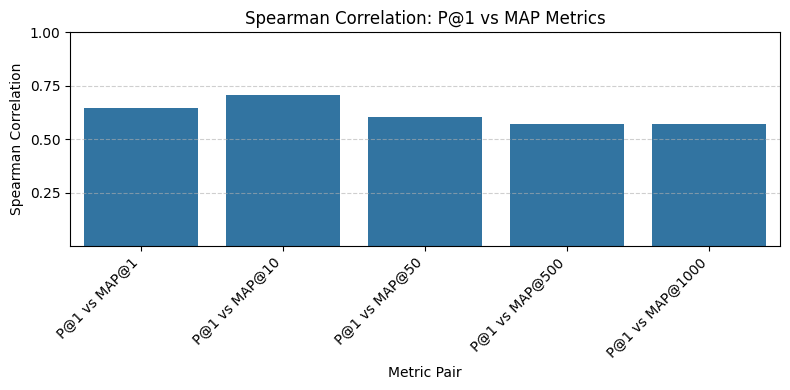

In [ ]:
# P@1 vs MAP metrics
p1_vs_map_df = calculate_metric_block('P@1', map_cols)
display(p1_vs_map_df)
plot_correlation_bar(p1_vs_map_df, "Spearman Correlation: P@1 vs MAP Metrics")

,Metric Pair,Spearman Correlation,p-value
0,P@10 vs MAP@1,0.448615,0.093488
1,P@10 vs MAP@10,0.823950,0.000159
2,P@10 vs MAP@50,0.807864,0.000269
3,P@10 vs MAP@500,0.813226,0.000227
4,P@10 vs MAP@1000,0.813226,0.000227


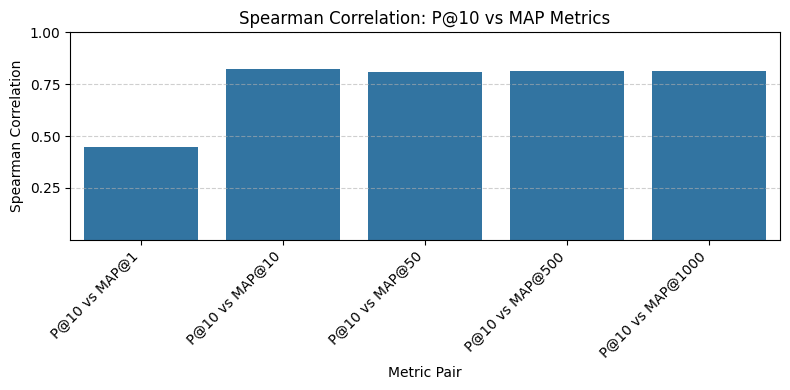

In [30]:
# P@10 vs MAP metrics
p10_vs_map_df = calculate_metric_block('P@10', map_cols)
display(p10_vs_map_df)
plot_correlation_bar(p10_vs_map_df, "Spearman Correlation: P@10 vs MAP Metrics")

,Metric Pair,Spearman Correlation,p-value
0,P@50 vs MAP@1,0.507143,0.053664
1,P@50 vs MAP@10,0.832143,0.000119
2,P@50 vs MAP@50,0.889286,0.000009
3,P@50 vs MAP@500,0.878571,0.000016
4,P@50 vs MAP@1000,0.878571,0.000016


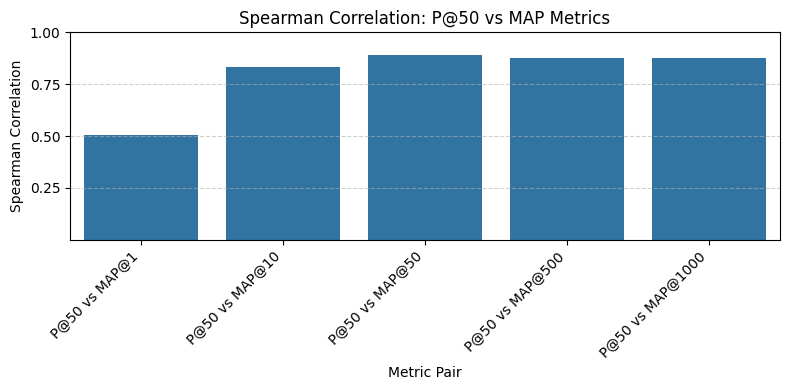

In [31]:
# P@50 vs MAP metrics
p50_vs_map_df = calculate_metric_block('P@50', map_cols)
display(p50_vs_map_df)
plot_correlation_bar(p50_vs_map_df, "Spearman Correlation: P@50 vs MAP Metrics")


,Metric Pair,Spearman Correlation,p-value
0,P@500 vs MAP@1,0.546429,3.506666e-02
1,P@500 vs MAP@10,0.871429,2.323648e-05
2,P@500 vs MAP@50,0.932143,4.241218e-07
3,P@500 vs MAP@500,0.957143,2.273675e-08
4,P@500 vs MAP@1000,0.957143,2.273675e-08


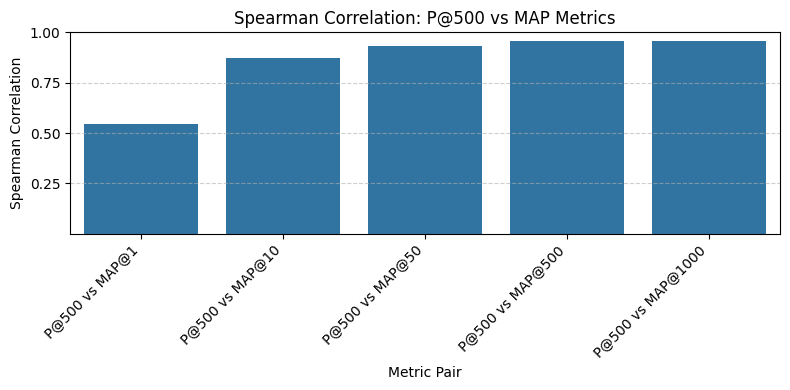

In [32]:
# P@500 vs MAP metrics
p500_vs_map_df = calculate_metric_block('P@500', map_cols)
display(p500_vs_map_df)
plot_correlation_bar(p500_vs_map_df, "Spearman Correlation: P@500 vs MAP Metrics")


,Metric Pair,Spearman Correlation,p-value
0,P@1000 vs MAP@1,0.600000,1.805009e-02
1,P@1000 vs MAP@10,0.885714,1.119982e-05
2,P@1000 vs MAP@50,0.907143,3.063311e-06
3,P@1000 vs MAP@500,0.932143,4.241218e-07
4,P@1000 vs MAP@1000,0.932143,4.241218e-07


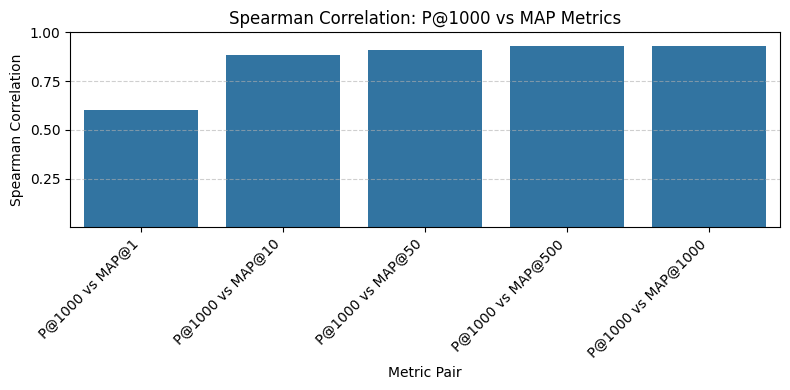

In [33]:
# P@1000 vs MAP metrics
p1000_vs_map_df = calculate_metric_block('P@1000', map_cols)
display(p1000_vs_map_df)
plot_correlation_bar(p1000_vs_map_df, "Spearman Correlation: P@1000 vs MAP Metrics")


,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000
P@1,0.645031,0.706462,0.603474,0.569145,0.569145
P@10,0.448615,0.823950,0.807864,0.813226,0.813226
P@50,0.507143,0.832143,0.889286,0.878571,0.878571
P@500,0.546429,0.871429,0.932143,0.957143,0.957143
P@1000,0.600000,0.885714,0.907143,0.932143,0.932143


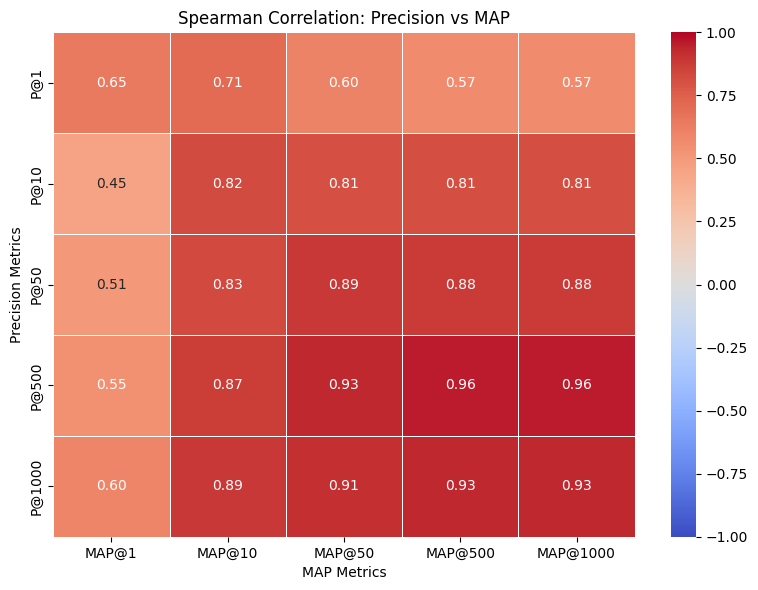

In [34]:
# Precision vs MAP heatmap
precision_map_corr = cross_metric_corr_matrix(precision_cols, map_cols)

display(precision_map_corr)

plot_heatmap(
    precision_map_corr,
    "Spearman Correlation: Precision vs MAP",
    "MAP Metrics",
    "Precision Metrics"
)


#### Precision vs nDCG

,Metric Pair,Spearman Correlation,p-value
0,P@1 vs nDCG@1,1.000000,0.000000
1,P@1 vs nDCG@10,0.789576,0.000464
2,P@1 vs nDCG@50,0.673940,0.005870
3,P@1 vs nDCG@500,0.616122,0.014455
4,P@1 vs nDCG@1000,0.592633,0.019905


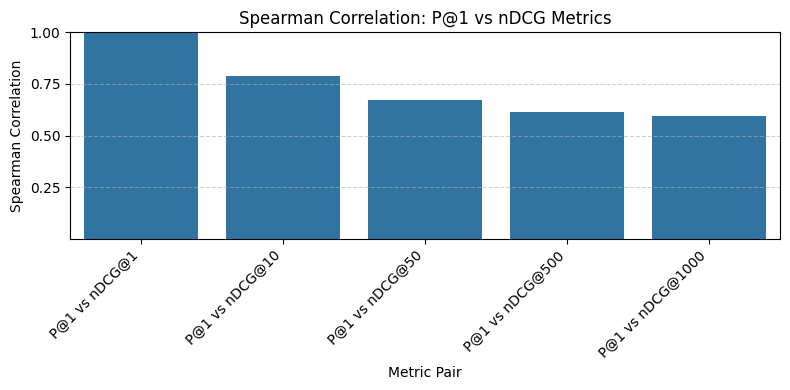

In [35]:
# P@1 vs nDCG metrics
p1_vs_ndcg_df = calculate_metric_block('P@1', ndcg_cols)
display(p1_vs_ndcg_df)
plot_correlation_bar(p1_vs_ndcg_df, "Spearman Correlation: P@1 vs nDCG Metrics")

,Metric Pair,Spearman Correlation,p-value
0,P@10 vs nDCG@1,0.707094,3.198524e-03
1,P@10 vs nDCG@10,0.979446,2.021806e-10
2,P@10 vs nDCG@50,0.907954,2.899333e-06
3,P@10 vs nDCG@500,0.775693,6.771826e-04
4,P@10 vs nDCG@1000,0.791779,4.353467e-04


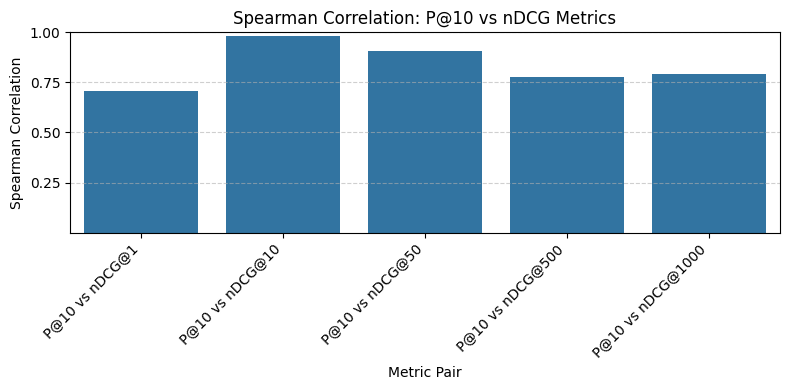

In [36]:
# P@10 vs nDCG metrics
p10_vs_ndcg_df = calculate_metric_block('P@10', ndcg_cols)
display(p10_vs_ndcg_df)
plot_correlation_bar(p10_vs_ndcg_df, "Spearman Correlation: P@10 vs nDCG Metrics")

,Metric Pair,Spearman Correlation,p-value
0,P@50 vs nDCG@1,0.579986,2.342533e-02
1,P@50 vs nDCG@10,0.889286,9.192975e-06
2,P@50 vs nDCG@50,0.957143,2.273675e-08
3,P@50 vs nDCG@500,0.832143,1.190282e-04
4,P@50 vs nDCG@1000,0.839286,9.136936e-05


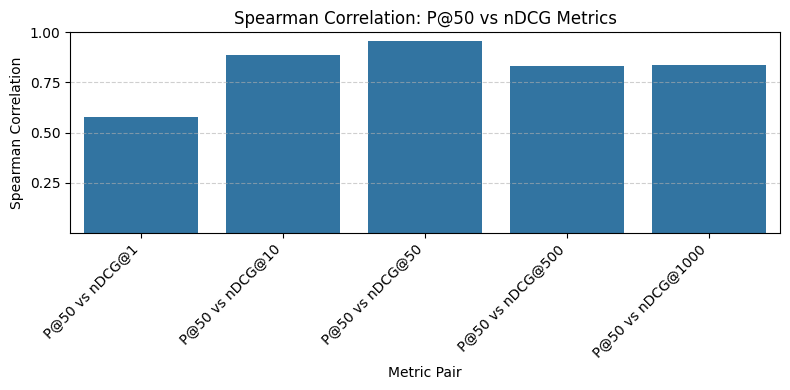

In [37]:
# P@50 vs nDCG metrics
p50_vs_ndcg_df = calculate_metric_block('P@50', ndcg_cols)
display(p50_vs_ndcg_df)
plot_correlation_bar(p50_vs_ndcg_df, "Spearman Correlation: P@50 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,P@500 vs nDCG@1,0.527588,4.325675e-02
1,P@500 vs nDCG@10,0.825000,1.532356e-04
2,P@500 vs nDCG@50,0.885714,1.119982e-05
3,P@500 vs nDCG@500,0.950000,6.086258e-08
4,P@500 vs nDCG@1000,0.964286,7.072303e-09


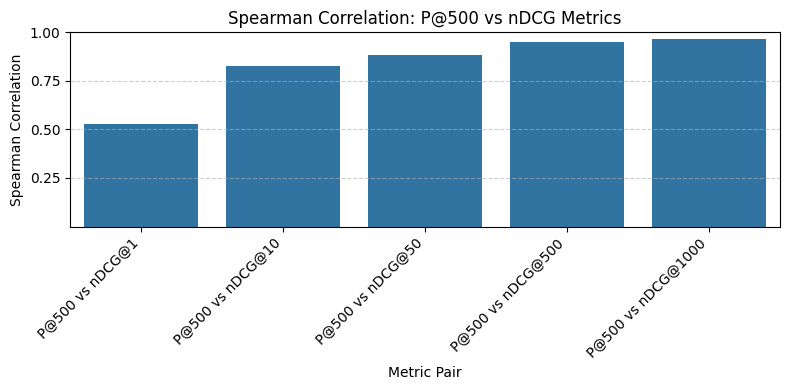

In [38]:
# P@500 vs nDCG metrics
p500_vs_ndcg_df = calculate_metric_block('P@500', ndcg_cols)
display(p500_vs_ndcg_df)
plot_correlation_bar(p500_vs_ndcg_df, "Spearman Correlation: P@500 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,P@1000 vs nDCG@1,0.543850,3.611300e-02
1,P@1000 vs nDCG@10,0.796429,3.804677e-04
2,P@1000 vs nDCG@50,0.853571,5.173144e-05
3,P@1000 vs nDCG@500,0.950000,6.086258e-08
4,P@1000 vs nDCG@1000,0.964286,7.072303e-09


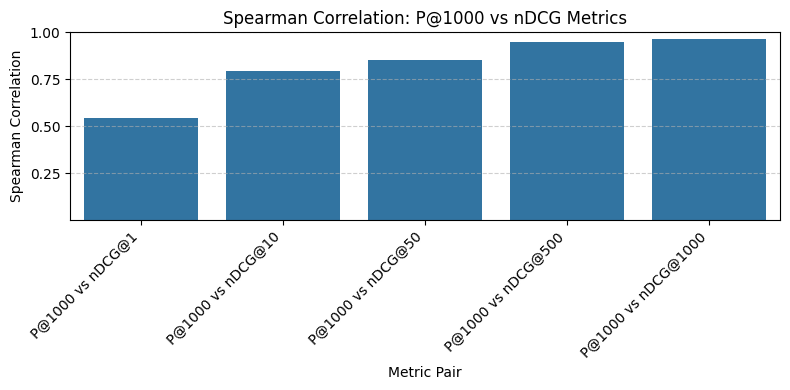

In [39]:
# P@1000 vs nDCG metrics
p1000_vs_ndcg_df = calculate_metric_block('P@1000', ndcg_cols)
display(p1000_vs_ndcg_df)
plot_correlation_bar(p1000_vs_ndcg_df, "Spearman Correlation: P@1000 vs nDCG Metrics")


,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
P@1,1.000000,0.789576,0.673940,0.616122,0.592633
P@10,0.707094,0.979446,0.907954,0.775693,0.791779
P@50,0.579986,0.889286,0.957143,0.832143,0.839286
P@500,0.527588,0.825000,0.885714,0.950000,0.964286
P@1000,0.543850,0.796429,0.853571,0.950000,0.964286


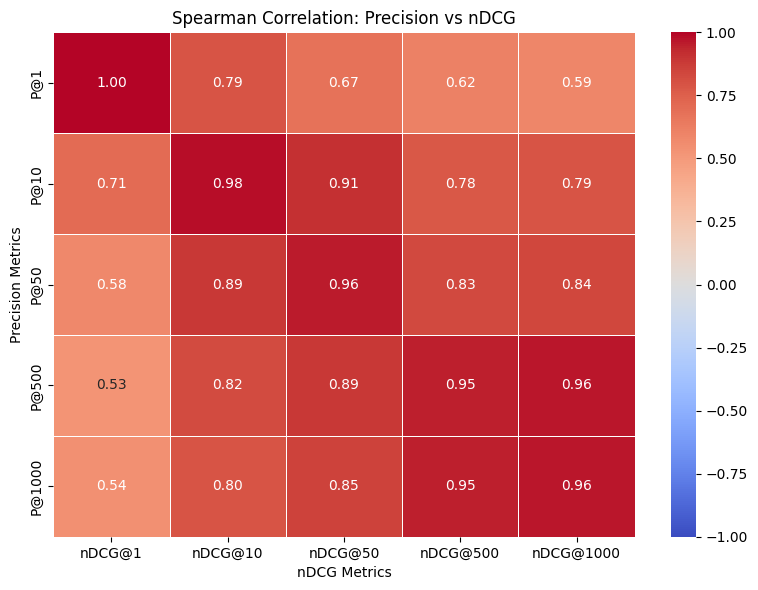

In [40]:
# Precision vs nDCG heatmap
precision_ndcg_corr = cross_metric_corr_matrix(precision_cols, ndcg_cols)

display(precision_ndcg_corr)

plot_heatmap(
    precision_ndcg_corr,
    "Spearman Correlation: Precision vs nDCG",
    "nDCG Metrics",
    "Precision Metrics"
)


#### MAP vs nDCG

,Metric Pair,Spearman Correlation,p-value
0,MAP@1 vs nDCG@1,0.645031,0.009417
1,MAP@1 vs nDCG@10,0.507143,0.053664
2,MAP@1 vs nDCG@50,0.592857,0.019846
3,MAP@1 vs nDCG@500,0.710714,0.002979
4,MAP@1 vs nDCG@1000,0.667857,0.006510


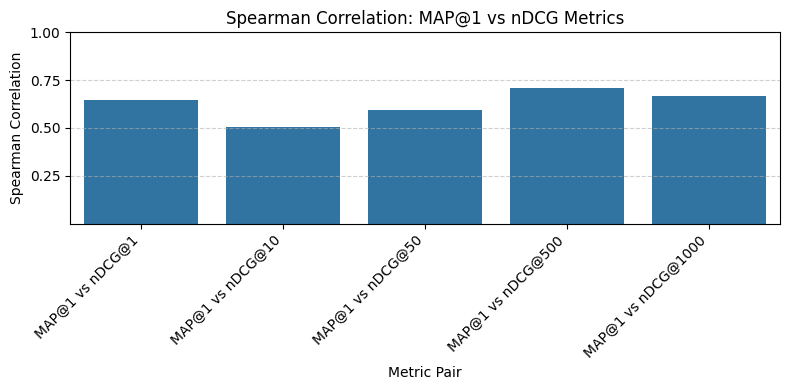

In [41]:
# MAP@1 vs nDCG metrics
map1_vs_ndcg_df = calculate_metric_block('MAP@1', ndcg_cols)
display(map1_vs_ndcg_df)
plot_correlation_bar(map1_vs_ndcg_df, "Spearman Correlation: MAP@1 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,MAP@10 vs nDCG@1,0.706462,0.003238
1,MAP@10 vs nDCG@10,0.864286,0.000032
2,MAP@10 vs nDCG@50,0.910714,0.000002
3,MAP@10 vs nDCG@500,0.910714,0.000002
4,MAP@10 vs nDCG@1000,0.914286,0.000002


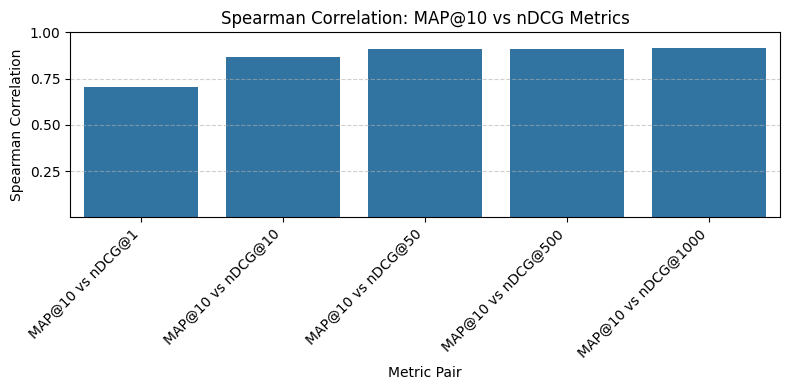

In [42]:
# MAP@10 vs nDCG metrics
map10_vs_ndcg_df = calculate_metric_block('MAP@10', ndcg_cols)
display(map10_vs_ndcg_df)
plot_correlation_bar(map10_vs_ndcg_df, "Spearman Correlation: MAP@10 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,MAP@50 vs nDCG@1,0.603474,1.722283e-02
1,MAP@50 vs nDCG@10,0.807143,2.752443e-04
2,MAP@50 vs nDCG@50,0.935714,3.010646e-07
3,MAP@50 vs nDCG@500,0.982143,8.157334e-11
4,MAP@50 vs nDCG@1000,0.978571,2.645456e-10


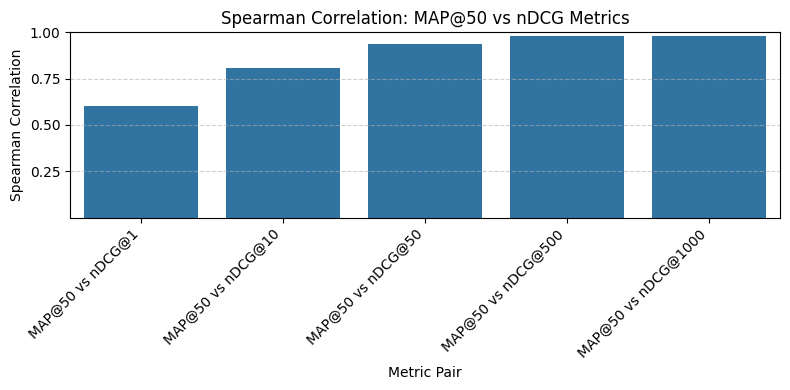

In [43]:
# MAP@50 vs nDCG metrics
map50_vs_ndcg_df = calculate_metric_block('MAP@50', ndcg_cols)
display(map50_vs_ndcg_df)
plot_correlation_bar(map50_vs_ndcg_df, "Spearman Correlation: MAP@50 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,MAP@500 vs nDCG@1,0.569145,2.680377e-02
1,MAP@500 vs nDCG@10,0.807143,2.752443e-04
2,MAP@500 vs nDCG@50,0.925000,7.987462e-07
3,MAP@500 vs nDCG@500,0.985714,1.929095e-11
4,MAP@500 vs nDCG@1000,0.989286,2.998934e-12


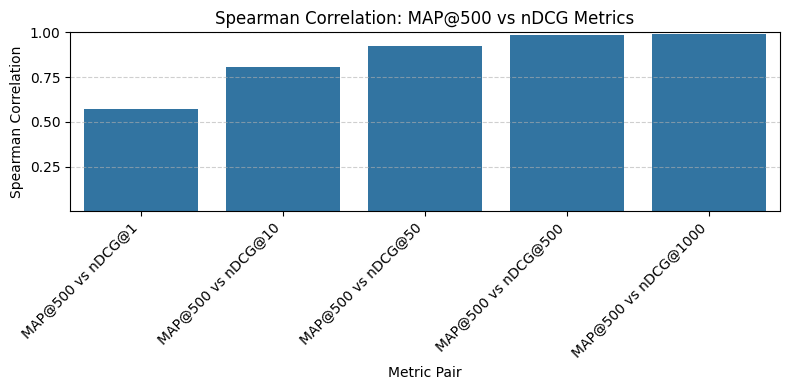

In [44]:
# MAP@500 vs nDCG metrics
map500_vs_ndcg_df = calculate_metric_block('MAP@500', ndcg_cols)
display(map500_vs_ndcg_df)
plot_correlation_bar(map500_vs_ndcg_df, "Spearman Correlation: MAP@500 vs nDCG Metrics")


,Metric Pair,Spearman Correlation,p-value
0,MAP@1000 vs nDCG@1,0.569145,2.680377e-02
1,MAP@1000 vs nDCG@10,0.807143,2.752443e-04
2,MAP@1000 vs nDCG@50,0.925000,7.987462e-07
3,MAP@1000 vs nDCG@500,0.985714,1.929095e-11
4,MAP@1000 vs nDCG@1000,0.989286,2.998934e-12


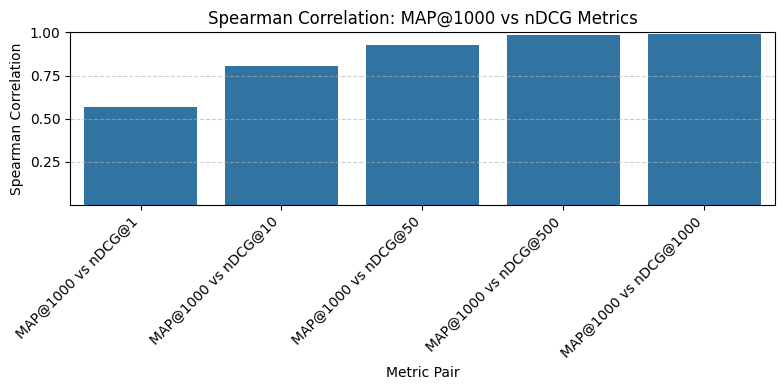

In [45]:
# MAP@1000 vs nDCG metrics
map1000_vs_ndcg_df = calculate_metric_block('MAP@1000', ndcg_cols)
display(map1000_vs_ndcg_df)
plot_correlation_bar(map1000_vs_ndcg_df, "Spearman Correlation: MAP@1000 vs nDCG Metrics")


,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
MAP@1,0.645031,0.507143,0.592857,0.710714,0.667857
MAP@10,0.706462,0.864286,0.910714,0.910714,0.914286
MAP@50,0.603474,0.807143,0.935714,0.982143,0.978571
MAP@500,0.569145,0.807143,0.925000,0.985714,0.989286
MAP@1000,0.569145,0.807143,0.925000,0.985714,0.989286


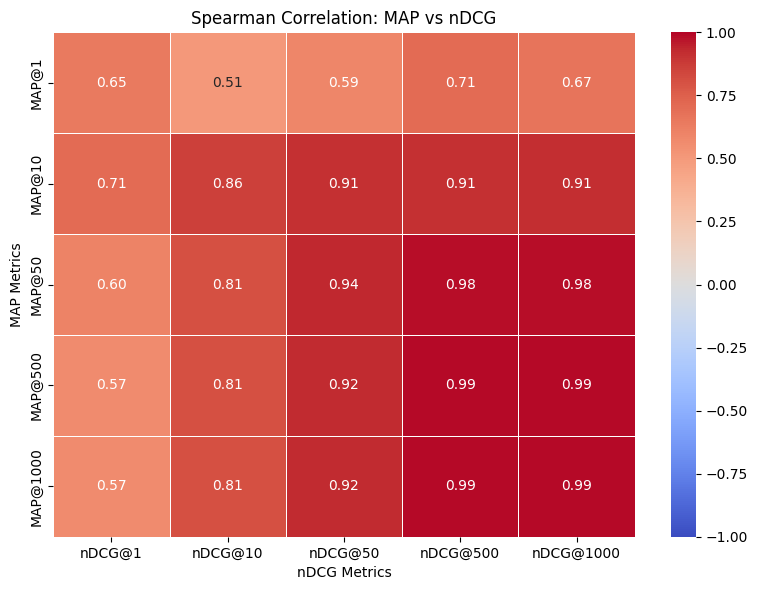

In [46]:
# MAP vs nDCG heatmap
map_ndcg_corr = cross_metric_corr_matrix(map_cols, ndcg_cols)

display(map_ndcg_corr)

plot_heatmap(
    map_ndcg_corr,
    "Spearman Correlation: MAP vs nDCG",
    "nDCG Metrics",
    "MAP Metrics"
)


### 3.2 Same Metric Across Depth

In [47]:
precision_comparison = pd.DataFrame({
    'P@1': p1_df.loc[p1_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'P@10': p10_df.loc[p10_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'P@50': p50_df.loc[p50_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'P@500': p500_df.loc[p500_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'P@1000': p1000_df.loc[p1000_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze()
})

precision_comparison.columns = ['P@1', 'P@10', 'P@50', 'P@500', 'P@1000']
precision_comparison = precision_comparison.drop(index='Overall', errors='ignore')
print(precision_comparison)

             P@1   P@10    P@50    P@500   P@1000
CL99XT      0.74  0.692  0.4032  0.11728  0.06734
Dm8TFidf    0.56  0.344  0.1992  0.06044  0.03844
GE8ATDN2    0.60  0.512  0.3200  0.10172  0.06136
INQ601      0.44  0.436  0.2896  0.08716  0.05402
Mer8Adtd2   0.60  0.444  0.2788  0.09000  0.05662
acsys8alo   0.58  0.530  0.3452  0.11024  0.06624
acsys8alo2  0.60  0.474  0.3168  0.10096  0.06160
apl8c621    0.66  0.504  0.3196  0.10988  0.06670
apl8ctd     0.56  0.450  0.2984  0.10260  0.06234
att99atde   0.62  0.548  0.3572  0.11004  0.06512
fub99a      0.70  0.530  0.3396  0.10880  0.06524
ibms99b     0.56  0.460  0.3192  0.10252  0.06302
nttd8ale    0.66  0.494  0.3276  0.10376  0.06240
ok8asxc     0.58  0.488  0.3220  0.10120  0.06026
pir9Attd    0.58  0.508  0.3456  0.11168  0.06684


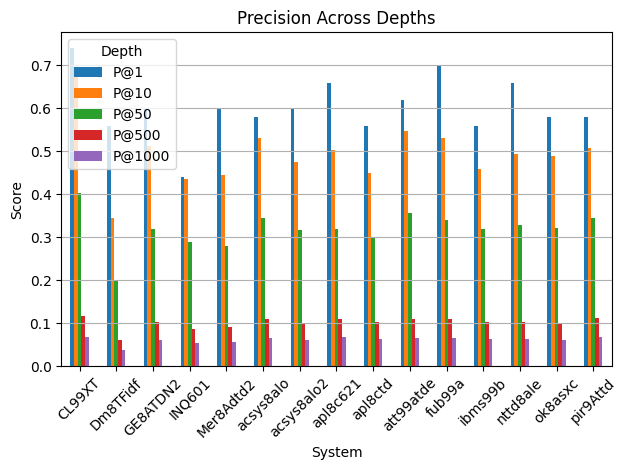

In [48]:
precision_comparison.plot(kind='bar')
plt.title('Precision Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()

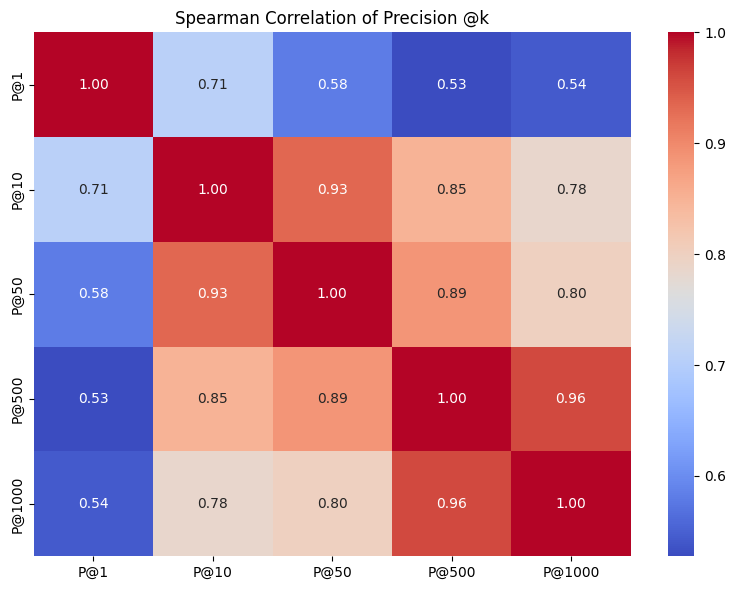

In [49]:
precision_depth_corr = precision_comparison.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(precision_depth_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation of Precision @k")
plt.tight_layout()
plt.show()

In [50]:
map_comparison = pd.DataFrame({
    'MAP@1': map1_df.loc[map1_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'MAP@10': map10_df.loc[map10_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'MAP@50': map50_df.loc[map50_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'MAP@500': map500_df.loc[map500_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'MAP@1000': map1000_df.loc[map1000_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
})
map_comparison = map_comparison.drop(index='Overall', errors='ignore')

print(map_comparison)

               MAP@1    MAP@10    MAP@50   MAP@500  MAP@1000
CL99XT      0.018643  0.130851  0.254829  0.365231  0.373043
Dm8TFidf    0.013362  0.073952  0.123216  0.158051  0.163035
GE8ATDN2    0.016207  0.088222  0.162401  0.249442  0.257968
INQ601      0.011858  0.080583  0.157460  0.224815  0.232549
Mer8Adtd2   0.014656  0.077695  0.146641  0.214131  0.223131
acsys8alo   0.014283  0.101239  0.191688  0.283580  0.293502
acsys8alo2  0.016356  0.095007  0.174114  0.254326  0.263668
apl8c621    0.017370  0.105636  0.200697  0.302168  0.312633
apl8ctd     0.016495  0.091294  0.182511  0.277154  0.285989
att99atde   0.014879  0.099052  0.201852  0.307403  0.316549
fub99a      0.018844  0.109134  0.198416  0.296584  0.306768
ibms99b     0.016415  0.086451  0.176557  0.268259  0.278388
nttd8ale    0.019208  0.101036  0.193072  0.282753  0.292138
ok8asxc     0.016912  0.096093  0.182632  0.270699  0.278696
pir9Attd    0.017008  0.102863  0.206589  0.310372  0.320659


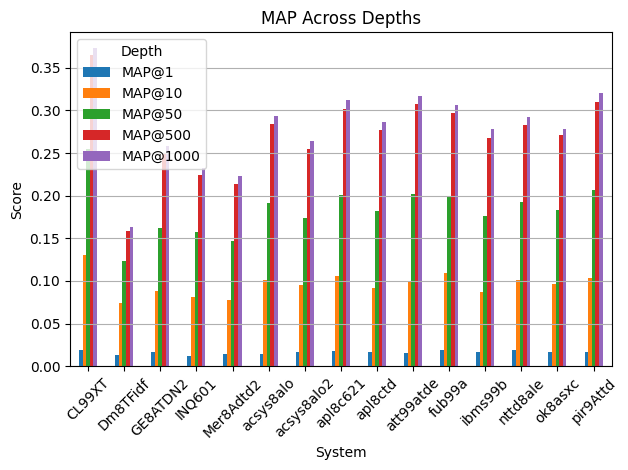

In [51]:
map_comparison.plot(kind='bar')
plt.title('MAP Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()

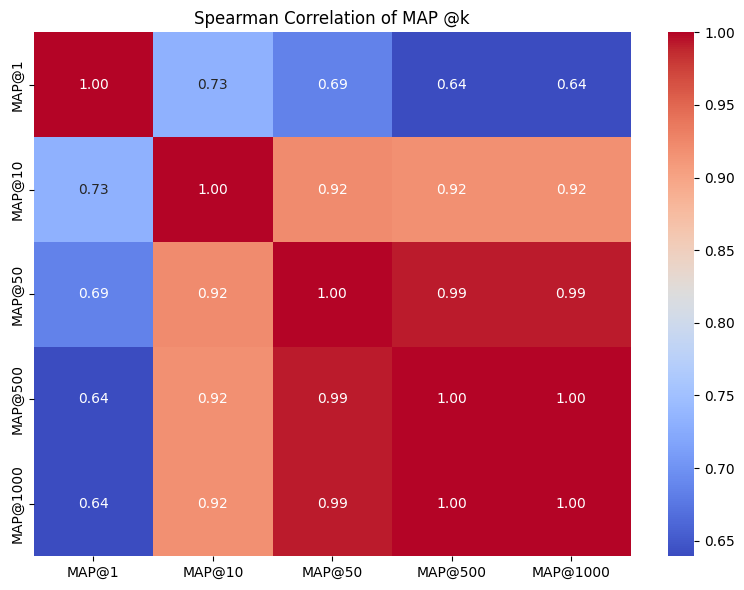

In [52]:
map_depth_corr = map_comparison.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(map_depth_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation of MAP @k")
plt.tight_layout()
plt.show()

In [53]:
ndcg_comparison = pd.DataFrame({
    'NDCG@1': ndcg1_df.loc[ndcg1_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'NDCG@10': ndcg10_df.loc[ndcg10_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'NDCG@50': ndcg50_df.loc[ndcg50_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'NDCG@500': ndcg500_df.loc[ndcg500_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
    'NDCG@1000': ndcg1000_df.loc[ndcg1000_df['query_id'] == 'Overall'].drop(columns=['query_id']).squeeze(),
})
ndcg_comparison = ndcg_comparison.drop(index='Overall', errors='ignore')

print(ndcg_comparison)


            NDCG@1   NDCG@10   NDCG@50  NDCG@500  NDCG@1000
CL99XT        0.74  0.716428  0.569267  0.635339   0.671461
Dm8TFidf      0.56  0.385672  0.310467  0.363569   0.399003
GE8ATDN2      0.60  0.536085  0.434540  0.517872   0.561775
INQ601        0.44  0.447578  0.397585  0.466935   0.509582
Mer8Adtd2     0.60  0.480382  0.395043  0.477580   0.526250
acsys8alo     0.58  0.543947  0.468979  0.554467   0.601051
acsys8alo2    0.60  0.499038  0.438665  0.519811   0.566490
apl8c621      0.66  0.539067  0.458823  0.577955   0.624432
apl8ctd       0.56  0.476374  0.419386  0.546654   0.590040
att99atde     0.62  0.562190  0.483185  0.573058   0.615255
fub99a        0.70  0.571617  0.473795  0.563089   0.608483
ibms99b       0.56  0.485459  0.436206  0.536144   0.585271
nttd8ale      0.66  0.527770  0.461871  0.554515   0.598381
ok8asxc       0.58  0.515674  0.440978  0.535453   0.576401
pir9Attd      0.58  0.531018  0.473474  0.579152   0.625149


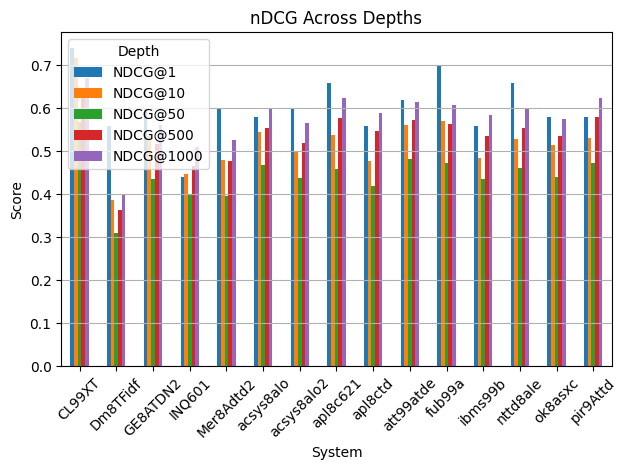

In [54]:
ndcg_comparison.plot(kind='bar')
plt.title('nDCG Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()

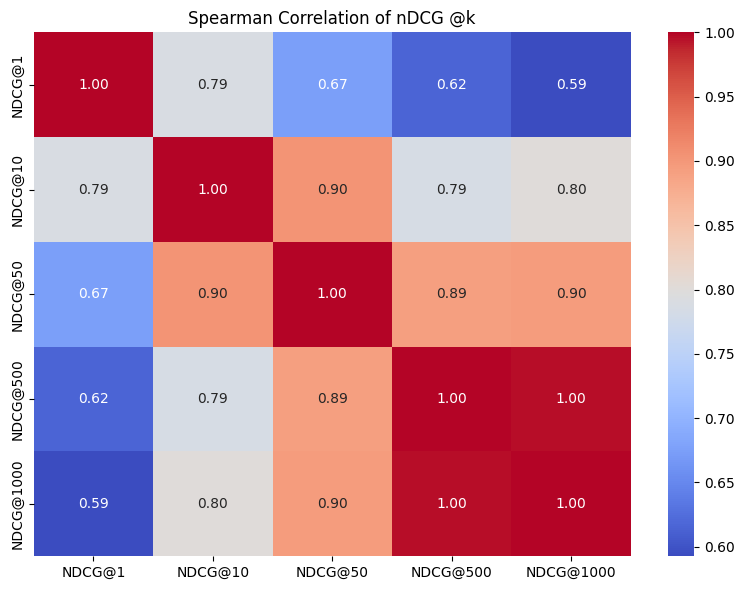

In [55]:
ndcg_depth_corr = ndcg_comparison.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(ndcg_depth_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation of nDCG @k")
plt.tight_layout()
plt.show()

### 3.3 All Metrics Spearman Correlation

=== All Metrics Comparison Table ===


,P@1,P@10,P@50,P@500,P@1000,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
System,,,,,,,,,,,,,,,
CL99XT,0.74,0.692,0.4032,0.11728,0.06734,0.018643,0.130851,0.254829,0.365231,0.373043,0.74,0.716428,0.569267,0.635339,0.671461
Dm8TFidf,0.56,0.344,0.1992,0.06044,0.03844,0.013362,0.073952,0.123216,0.158051,0.163035,0.56,0.385672,0.310467,0.363569,0.399003
GE8ATDN2,0.60,0.512,0.3200,0.10172,0.06136,0.016207,0.088222,0.162401,0.249442,0.257968,0.60,0.536085,0.434540,0.517872,0.561775
INQ601,0.44,0.436,0.2896,0.08716,0.05402,0.011858,0.080583,0.157460,0.224815,0.232549,0.44,0.447578,0.397585,0.466935,0.509582
Mer8Adtd2,0.60,0.444,0.2788,0.09000,0.05662,0.014656,0.077695,0.146641,0.214131,0.223131,0.60,0.480382,0.395043,0.477580,0.526250
acsys8alo,0.58,0.530,0.3452,0.11024,0.06624,0.014283,0.101239,0.191688,0.283580,0.293502,0.58,0.543947,0.468979,0.554467,0.601051
acsys8alo2,0.60,0.474,0.3168,0.10096,0.06160,0.016356,0.095007,0.174114,0.254326,0.263668,0.60,0.499038,0.438665,0.519811,0.566490
apl8c621,0.66,0.504,0.3196,0.10988,0.06670,0.017370,0.105636,0.200697,0.302168,0.312633,0.66,0.539067,0.458823,0.577955,0.624432
apl8ctd,0.56,0.450,0.2984,0.10260,0.06234,0.016495,0.091294,0.182511,0.277154,0.285989,0.56,0.476374,0.419386,0.546654,0.590040


=== Spearman Correlation Matrix for All Metrics ===


,P@1,P@10,P@50,P@500,P@1000,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
P@1,1.000000,0.707094,0.579986,0.527588,0.543850,0.645031,0.706462,0.603474,0.569145,0.569145,1.000000,0.789576,0.673940,0.616122,0.592633
P@10,0.707094,1.000000,0.934764,0.848973,0.784629,0.448615,0.823950,0.807864,0.813226,0.813226,0.707094,0.979446,0.907954,0.775693,0.791779
P@50,0.579986,0.934764,1.000000,0.885714,0.800000,0.507143,0.832143,0.889286,0.878571,0.878571,0.579986,0.889286,0.957143,0.832143,0.839286
P@500,0.527588,0.848973,0.885714,1.000000,0.960714,0.546429,0.871429,0.932143,0.957143,0.957143,0.527588,0.825000,0.885714,0.950000,0.964286
P@1000,0.543850,0.784629,0.800000,0.960714,1.000000,0.600000,0.885714,0.907143,0.932143,0.932143,0.543850,0.796429,0.853571,0.950000,0.964286
MAP@1,0.645031,0.448615,0.507143,0.546429,0.600000,1.000000,0.732143,0.685714,0.639286,0.639286,0.645031,0.507143,0.592857,0.710714,0.667857
MAP@10,0.706462,0.823950,0.832143,0.871429,0.885714,0.732143,1.000000,0.921429,0.917857,0.917857,0.706462,0.864286,0.910714,0.910714,0.914286
MAP@50,0.603474,0.807864,0.889286,0.932143,0.907143,0.685714,0.921429,1.000000,0.992857,0.992857,0.603474,0.807143,0.935714,0.982143,0.978571
MAP@500,0.569145,0.813226,0.878571,0.957143,0.932143,0.639286,0.917857,0.992857,1.000000,1.000000,0.569145,0.807143,0.925000,0.985714,0.989286
MAP@1000,0.569145,0.813226,0.878571,0.957143,0.932143,0.639286,0.917857,0.992857,1.000000,1.000000,0.569145,0.807143,0.925000,0.985714,0.989286


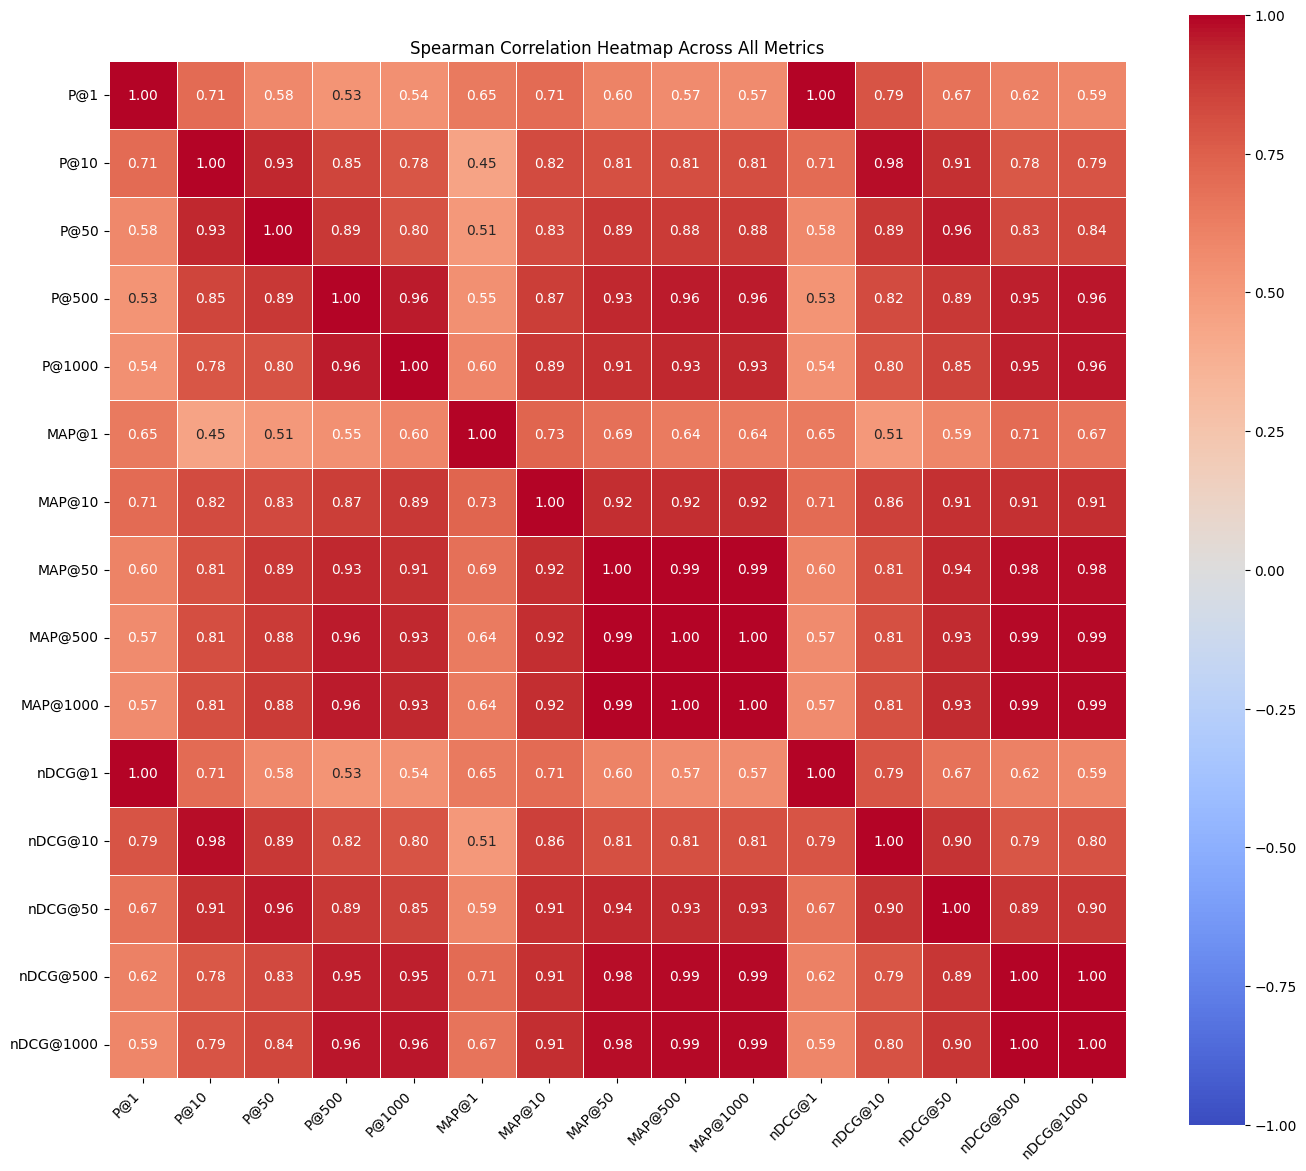

In [ ]:
all_metric_comparison = pd.DataFrame({
    'P@1': p1_df[p1_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'P@10': p10_df[p10_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'P@50': p50_df[p50_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'P@500': p500_df[p500_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'P@1000': p1000_df[p1000_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),

    'MAP@1': map1_df[map1_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'MAP@10': map10_df[map10_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'MAP@50': map50_df[map50_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'MAP@500': map500_df[map500_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'MAP@1000': map1000_df[map1000_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),

    'nDCG@1': ndcg1_df[ndcg1_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'nDCG@10': ndcg10_df[ndcg10_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'nDCG@50': ndcg50_df[ndcg50_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'nDCG@500': ndcg500_df[ndcg500_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze(),
    'nDCG@1000': ndcg1000_df[ndcg1000_df['query_id'] == 'Overall'].drop(columns='query_id').squeeze()
})

all_metric_comparison.index.name = 'System'
all_metric_comparison = all_metric_comparison.drop(index='Overall', errors='ignore')

print("=== All Metrics Comparison Table ===")
display(all_metric_comparison)

all_metric_corr = all_metric_comparison.corr(method='spearman')

print("=== Spearman Correlation Matrix for All Metrics ===")
display(all_metric_corr)

plt.figure(figsize=(14, 12))
sns.heatmap(
    all_metric_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap Across All Metrics")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

all_metric_comparison.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/all_metric_comparison.csv"
)

all_metric_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/all_metric_spearman_correlation.csv"
)


In [58]:
# ==============================
# Combine Cross-Metric Pair Results
# ==============================

precision_vs_map_df = pd.concat(
    [p1_vs_map_df, p10_vs_map_df, p50_vs_map_df, p500_vs_map_df, p1000_vs_map_df],
    ignore_index=True
)

precision_vs_ndcg_df = pd.concat(
    [p1_vs_ndcg_df, p10_vs_ndcg_df, p50_vs_ndcg_df, p500_vs_ndcg_df, p1000_vs_ndcg_df],
    ignore_index=True
)

map_vs_ndcg_df = pd.concat(
    [map1_vs_ndcg_df, map10_vs_ndcg_df, map50_vs_ndcg_df, map500_vs_ndcg_df, map1000_vs_ndcg_df],
    ignore_index=True
)

display(precision_vs_map_df)
display(precision_vs_ndcg_df)
display(map_vs_ndcg_df)


,Metric Pair,Spearman Correlation,p-value
0,P@1 vs MAP@1,0.645031,9.417450e-03
1,P@1 vs MAP@10,0.706462,3.238113e-03
2,P@1 vs MAP@50,0.603474,1.722283e-02
3,P@1 vs MAP@500,0.569145,2.680377e-02
4,P@1 vs MAP@1000,0.569145,2.680377e-02
5,P@10 vs MAP@1,0.448615,9.348821e-02
6,P@10 vs MAP@10,0.823950,1.588820e-04
7,P@10 vs MAP@50,0.807864,2.691187e-04
8,P@10 vs MAP@500,0.813226,2.270083e-04
9,P@10 vs MAP@1000,0.813226,2.270083e-04


,Metric Pair,Spearman Correlation,p-value
0,P@1 vs nDCG@1,1.000000,0.000000e+00
1,P@1 vs nDCG@10,0.789576,4.635116e-04
2,P@1 vs nDCG@50,0.673940,5.869792e-03
3,P@1 vs nDCG@500,0.616122,1.445505e-02
4,P@1 vs nDCG@1000,0.592633,1.990480e-02
5,P@10 vs nDCG@1,0.707094,3.198524e-03
6,P@10 vs nDCG@10,0.979446,2.021806e-10
7,P@10 vs nDCG@50,0.907954,2.899333e-06
8,P@10 vs nDCG@500,0.775693,6.771826e-04
9,P@10 vs nDCG@1000,0.791779,4.353467e-04


,Metric Pair,Spearman Correlation,p-value
0,MAP@1 vs nDCG@1,0.645031,9.417450e-03
1,MAP@1 vs nDCG@10,0.507143,5.366366e-02
2,MAP@1 vs nDCG@50,0.592857,1.984642e-02
3,MAP@1 vs nDCG@500,0.710714,2.978995e-03
4,MAP@1 vs nDCG@1000,0.667857,6.509957e-03
5,MAP@10 vs nDCG@1,0.706462,3.238113e-03
6,MAP@10 vs nDCG@10,0.864286,3.243373e-05
7,MAP@10 vs nDCG@50,0.910714,2.395021e-06
8,MAP@10 vs nDCG@500,0.910714,2.395021e-06
9,MAP@10 vs nDCG@1000,0.914286,1.853112e-06


### 3.4 Save Correlation Results

In [ ]:
os.makedirs(f"{OUTPUT_FOLDER}/Correlation_Results", exist_ok=True)

# Cross-metric pair results
precision_vs_map_df.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/precision_vs_map_pairs.csv",
    index=False
)

precision_vs_ndcg_df.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/precision_vs_ndcg_pairs.csv",
    index=False
)

map_vs_ndcg_df.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/map_vs_ndcg_pairs.csv",
    index=False
)

# Cross-metric heatmap matrices
precision_map_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/precision_vs_map_correlation_matrix.csv"
)

precision_ndcg_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/precision_vs_ndcg_correlation_matrix.csv"
)

map_ndcg_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/map_vs_ndcg_correlation_matrix.csv"
)

# Same metric across depth
precision_depth_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/precision_depth_correlation.csv"
)

map_depth_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/map_depth_correlation.csv"
)

ndcg_depth_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/ndcg_depth_correlation.csv"
)

# All metrics
all_metric_comparison = pd.DataFrame({
    metric: get_metric_scores(metric)
    for metric in precision_cols + map_cols + ndcg_cols
})

all_metric_corr = all_metric_comparison.corr(method='spearman')
all_metric_comparison.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/all_metric_comparison.csv"
)

all_metric_corr.to_csv(
    f"{OUTPUT_FOLDER}/Correlation_Results/all_metric_spearman_correlation.csv"
)

print("All correlation results saved successfully.")


All correlation results saved successfully.
